In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Ans to the Q1

In [31]:
employees = pd.read_csv('final-employee-ds.csv')

TrainingHours = np.array(employees['TrainingHours'], dtype='float64')

mean = np.mean(TrainingHours)
std = np.std(TrainingHours)

print(mean)
print(std)

24.19
13.842467265628624


# Ans to the Q2

In [7]:
dep_grp_med = employees.groupby('Department')['Salary'].median()

employees.loc[(employees['Department'] == 'Finance') & (employees['Salary'].isnull() == True), ['Salary']] = dep_grp_med.values[0]
employees.loc[(employees['Department'] == 'HR') & (employees['Salary'].isnull() == True), ['Salary']] = dep_grp_med.values[1]
employees.loc[(employees['Department'] == 'IT') & (employees['Salary'].isnull() == True), ['Salary']] = dep_grp_med.values[2]
employees.loc[(employees['Department'] == 'Management') & (employees['Salary'].isnull() == True), ['Salary']] = dep_grp_med.values[3]
employees.loc[(employees['Department'] == 'Marketing') & (employees['Salary'].isnull() == True), ['Salary']] = dep_grp_med.values[4]

# way 1
# df['Salary'] = df['Salary'].fillna(
#     df.groupby('Department')['Salary'].transform('median')
# )

# way 2
# dep_median = employees.groupby('Department')['Salary'].median()
# employees['Salary'] = employees['Salary'].fillna(employees['Department'].map(dep_median))

sum = employees.loc[(employees['ExperienceYears'] > 12) & (employees['ProjectCount'] > 5), 'Salary'].sum()
print(sum)

False
1985775.5


# Ans to the Q3

In [4]:
Filter_employees = (employees.loc[((employees['Department'] == 'IT') | (employees['Department'] == 'Finance')) & ((employees['Age'] >= 30) & (employees['Age'] <= 45)) & (employees['PerformanceScore'] > 88), ['Name', 'Department', 'Salary', 'PerformanceScore']]).sort_values(['Salary'], ascending=False)
print(Filter_employees)

           Name Department    Salary  PerformanceScore
94  Employee_95         IT  140386.0                94
88  Employee_89    Finance  126027.0                92
4    Employee_5    Finance   85543.0                97
32  Employee_33         IT   83919.0                98
55  Employee_56    Finance   49540.0                94


# Ans to the Q4

In [5]:
employees['SalaryPerHour'] = employees['Salary'] / (employees['WorkHoursPerWeek'] * 4)

sorted_by_SalaryPerHour = employees.sort_values('SalaryPerHour', ascending=False)

print(sorted_by_SalaryPerHour[['Name', 'SalaryPerHour']].head(5))

           Name  SalaryPerHour
46  Employee_47     981.278571
27  Employee_28     971.292857
31  Employee_32     967.392857
79  Employee_80     945.335526
80  Employee_81     937.858974


<Axes: xlabel='Department', ylabel='count'>

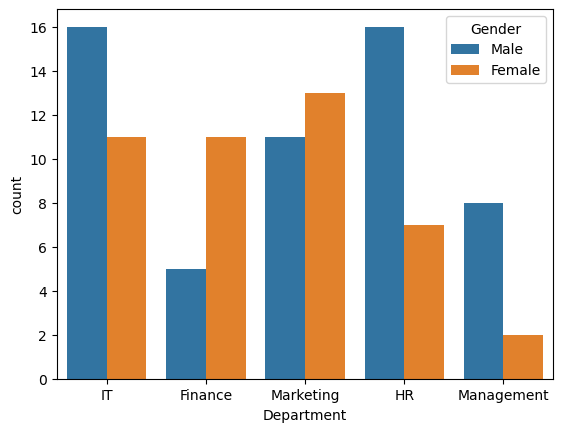

In [6]:
sns.countplot(data=employees, x=employees['Department'], hue='Gender')

In [12]:
employees.groupby('Department')['Salary'].median()

Department
Finance        91991.0
HR             84078.0
IT            104272.5
Management    106801.0
Marketing     110766.5
Name: Salary, dtype: float64

In [24]:
null_value = employees.loc[employees['Salary'].isnull() == True]
null_value

,EmployeeID,Name,Age,Gender,Department,ExperienceYears,Salary,WorkHoursPerWeek,PerformanceScore,JoinDate,Tshirt_size,ProjectCount,TrainingHours,DepartmentRating
9,110,Employee_10,57,Male,IT,19,NaN,44,86,2021-05-21,M,8,17,2
19,120,Employee_20,54,Female,Finance,3,NaN,47,76,2015-06-24,M,6,14,5
49,150,Employee_50,27,Female,Finance,16,NaN,38,80,2017-09-15,M,5,32,4
89,190,Employee_90,29,Female,Finance,18,NaN,48,79,2014-09-16,M,7,22,2


In [29]:
employees['Salary'] = employees['Salary'].fillna(
    employees.groupby('Department')['Salary'].transform('median')
)

In [30]:
employees['Salary'].hasnans

False